In [ ]:
import wandb # KEY: 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
from ultralytics import YOLOWorld
import torch


# 1. Initialize W&B project
wandb.init(project="phobia-detector-yoloworld", job_type="training")

# 2. Load the YOLO-World model
# Using 'v2' models is highly recommended for custom training
model = YOLOWorld('yolov8s-worldv2.pt')

# 3. Fine-tune
# The 'data' parameter points to the data.yaml file provided by Roboflow
try:
    device = 'xpu' if torch.xpu.is_available() else 'cpu'
except ImportError:
    device = 'cpu'

print(f"Using device: {device}")

model.train(
    data='insects-2/data.yaml',
    epochs=15,
    patience=5,
    imgsz=224,
    batch=-1,
    device=device,      
    project="phobia-detector",
    name="insect_finetune",
    freeze=10,
    lr0=0.01,
    plots=True,
    mosaic=0.0,        # OFF: Don't combine 4 images into one (bad for small 224px imgs)
    mixup=0.0,         # OFF: Don't blend two images
    fliplr=0.5,        # ON: Random horizontal flip (insects look the same either way)
    flipud=0.0,        # OFF: Usually insects aren't seen upside down unless dead
    hsv_h=0.015,       # ON: Very slight color hue shift
    hsv_s=0.7,         # ON: Saturation shift
    hsv_v=0.4,         # ON: Brightness shift (helps with indoor/outdoor lighting)
    degrees=0.0,       # OFF: No rotation for this quick test
    scale=0.5,         # ON: Random zoom in/out to handle distance
    translate=0.1
)

# 4. Finish the W&B run
wandb.finish()

Using device: cpu
Ultralytics 8.4.21 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (Intel Core Ultra 7 256V)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=insects-2/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-worldv2.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=insect_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

wandb: ERROR The nbformat package was not found. It is required to save notebook history.



image 1/1 /home/aadit/FAI/final/Realtime-Phobia-Filter/insects-2/test/images/12_jpg.rf.6affb17d7f00774bb740b8c37b4234b0.jpg: 224x224 1 rice water weevil, 2036.4ms
Speed: 1.6ms preprocess, 2036.4ms inference, 3.2ms postprocess per image at shape (1, 3, 224, 224)


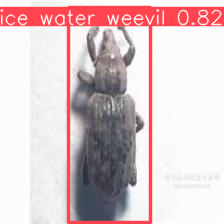

In [2]:
from ultralytics import YOLOWorld
model = YOLOWorld('runs/detect/phobia-detector/insect_finetune/weights/best.pt')

results = model.predict("insects-2/test/images/12_jpg.rf.6affb17d7f00774bb740b8c37b4234b0.jpg")
results[0].show()

In [4]:
import cv2
import collections

cap = cv2.VideoCapture('videoplayback.mp4')
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS)) 

out = cv2.VideoWriter('robust_blur.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

# --- IMPROVED PERSISTENCE SETTINGS ---
last_known_boxes = {}
frames_since_seen = collections.defaultdict(int) 
persistence_limit = 20  # Increased for safety
base_pad = 25           # Larger initial padding

while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    # Lowered confidence significantly; the tracker will handle the noise
    results = model.track(frame, persist=True, conf=0.15, imgsz=640, device='cpu')
    
    current_frame_ids = []
    if results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        for box, obj_id in zip(boxes, ids):
            last_known_boxes[obj_id] = box
            frames_since_seen[obj_id] = 0
            current_frame_ids.append(obj_id)

    for obj_id in list(last_known_boxes.keys()):
        if frames_since_seen[obj_id] < persistence_limit:
            x1, y1, x2, y2 = map(int, last_known_boxes[obj_id])
            
            # DYNAMIC PADDING: Box grows as it gets "older" to ensure coverage
            growth_factor = frames_since_seen[obj_id] * 5
            curr_pad = base_pad + growth_factor
            
            x1 = max(0, x1 - curr_pad)
            y1 = max(0, y1 - curr_pad)
            x2 = min(w, x2 + curr_pad)
            y2 = min(h, y2 + curr_pad)

            roi = frame[y1:y2, x1:x2]
            if roi.size > 0:
                # Use a larger kernel for a more "opaque" blur
                frame[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (101, 101), 0)
            
            if obj_id not in current_frame_ids:
                frames_since_seen[obj_id] += 1
        else:
            del last_known_boxes[obj_id]
            del frames_since_seen[obj_id]

    out.write(frame)

cap.release()
out.release()
print("Video saved as robust_blur.mp4")


0: 384x640 1 army worm, 1101.0ms
Speed: 80.9ms preprocess, 1101.0ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 182.3ms
Speed: 1.0ms preprocess, 182.3ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 148.6ms
Speed: 0.9ms preprocess, 148.6ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 156.5ms
Speed: 1.2ms preprocess, 156.5ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 army worm, 171.8ms
Speed: 0.9ms preprocess, 171.8ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 184.5ms
Speed: 1.0ms preprocess, 184.5ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 army worm, 219.8ms
Speed: 1.0ms preprocess, 219.8ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 189.3ms
Speed: 3.2ms preprocess, 18

In [6]:
from ultralytics import YOLOWorld

# 1. Load your fine-tuned PyTorch model
model = YOLOWorld('runs/detect/phobia-detector/insect_finetune/weights/best.pt')

# 2. Export to OpenVINO format
# imgsz: Must match what you want to use in the final app (e.g., 640)
# half: True converts to FP16, which is the "sweet spot" for Intel Arc
model.export(format='openvino', imgsz=640, half=True)

Ultralytics 8.4.21 🚀 Python-3.12.3 torch-2.10.0+xpu CPU (Intel Core Ultra 7 256V)
WARNING ⚠️ YOLOWorld (original version) export is not supported to any format. YOLOWorldv2 models (i.e. 'yolov8s-worldv2.pt') only support export to (torchscript, onnx, openvino, engine, coreml) formats. See https://docs.ultralytics.com/models/yolo-world for details.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8s-worldv2 summary (fused): 88 layers, 12,749,288 parameters, 0 gradients, 34.2 GFLOPs

PyTorch: starting from 'runs/detect/phobia-detector/insect_finetune/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (24.6 MB)
requirements: Ultralytics requirement ['openvino>=2024.0.0'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/53.4 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/53.4 MB 1.6 MB/s eta 0:00:34
   

'runs/detect/phobia-detector/insect_finetune/weights/best_openvino_model'

Loading runs/detect/phobia-detector/insect_finetune/weights/best_openvino_model/ for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...

image 1/1 /home/aadit/FAI/final/Realtime-Phobia-Filter/insects-2/test/images/12_jpg.rf.6affb17d7f00774bb740b8c37b4234b0.jpg: 640x640 2 legume blister beetles, 764.4ms
Speed: 30.8ms preprocess, 764.4ms inference, 73.2ms postprocess per image at shape (1, 3, 640, 640)


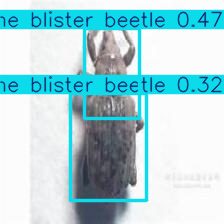

In [10]:
from ultralytics import YOLO
# Load the OpenVINO folder instead of the .pt file
# The library will automatically detect the .xml/.bin files inside
ov_model = YOLO('runs/detect/phobia-detector/insect_finetune/weights/best_openvino_model/')

# Run inference - it will automatically use your Arc GPU if drivers are ready
results = ov_model.predict('insects-2/test/images/12_jpg.rf.6affb17d7f00774bb740b8c37b4234b0.jpg', imgsz=640)
results[0].show()

## Video Blur with OpenVINO

In [13]:
import cv2
import collections

cap = cv2.VideoCapture('yellowriceborer.mp4')
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS)) 

out = cv2.VideoWriter('riceborerblur.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

# --- PERSISTENCE SETTINGS ---
# Stores the last known box for each insect ID {id: [x1, y1, x2, y2]}
last_known_boxes = {} 
# How many frames to keep blurring after the bug is lost (e.g., 5 frames)
persistence_limit = 5 
# Track how many frames ago we saw each ID
frames_since_seen = collections.defaultdict(int) 

while cap.isOpened():
    success, frame = cap.read()
    if not success: break

    # 2. Run Tracking (Persist=True is key)
    # Lowering conf slightly to 0.2 since we are using a tracker to filter noise
    results = ov_model.track(frame, persist=True, conf=0.2, imgsz=640, device='cpu')

    current_frame_ids = []

    for r in results:
        if r.boxes is not None and r.boxes.id is not None:
            boxes = r.boxes.xyxy.cpu().numpy()
            ids = r.boxes.id.cpu().numpy().astype(int)

            for box, obj_id in zip(boxes, ids):
                last_known_boxes[obj_id] = box
                frames_since_seen[obj_id] = 0
                current_frame_ids.append(obj_id)

    # 3. Process All Active Blurs (Actual detections + Persistent "ghost" boxes)
    for obj_id in list(last_known_boxes.keys()):
        if frames_since_seen[obj_id] < persistence_limit:
            x1, y1, x2, y2 = map(int, last_known_boxes[obj_id])
            
            # --- IMPROVEMENT: PADDING ---
            # Make the blur 20% larger than the box to catch legs/motion
            pad = 20
            x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
            x2, y2 = min(w, x2 + pad), min(h, y2 + pad)

            # Apply Blur
            roi = frame[y1:y2, x1:x2]
            if roi.size > 0:
                frame[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (99, 99), 0)
            
            # Increment the counter if we didn't see it this frame
            if obj_id not in current_frame_ids:
                frames_since_seen[obj_id] += 1
        else:
            # Clean up old data
            del last_known_boxes[obj_id]
            del frames_since_seen[obj_id]

    out.write(frame)

cap.release()
out.release()
print("Video saved as robust_blur.mp4")


0: 640x640 (no detections), 58.2ms
Speed: 38.2ms preprocess, 58.2ms inference, 33.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 41.2ms
Speed: 81.3ms preprocess, 41.2ms inference, 35.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 28.3ms
Speed: 34.5ms preprocess, 28.3ms inference, 34.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 yellow rice borer, 22.5ms
Speed: 25.7ms preprocess, 22.5ms inference, 31.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 45.1ms
Speed: 34.7ms preprocess, 45.1ms inference, 38.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 26.9ms
Speed: 31.1ms preprocess, 26.9ms inference, 31.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 40.8ms
Speed: 30.7ms preprocess, 40.8ms inference, 35.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 yellow rice borer, 33.1ms
Speed: 31.9